# MMT Relative Climate

## August 21, 2026
## Emily Zuetell

How does the climate and forecast relate to MMT? How does the distance to the MMT change and indicate risk?

In [1]:
# MMT vs forecast
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [11]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]
BETAS_PATH = os.environ["BETAS_PATH"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [4]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

In [42]:
betas = xr.open_zarr(os.path.join(DATA_DIR, BETAS_PATH)).sel(age_cohort="age65plus")
mmt = betas["mmt"]

In [43]:
min_val = betas["beta"].min(dim="tas_bin")
is_min = betas["beta"] == min_val
central_tas_bin = betas["tas_bin"].where(is_min).median(dim="tas_bin", skipna=True)

In [16]:
era5 = xr.open_zarr(os.path.join(DATA_DIR, ERA5_URI)).groupby("time.month").mean()
era5_ir = isku_utils.grid_to_ir(era5.compute(), savefile=None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [44]:
diff = era5_ir["tas"] - 273.15 - central_tas_bin.mean(dim="sample")

In [47]:
_polygons_mmt = analysis_utils.xarray_to_gpd(
    central_tas_bin.mean(dim="sample"), _polygons
)

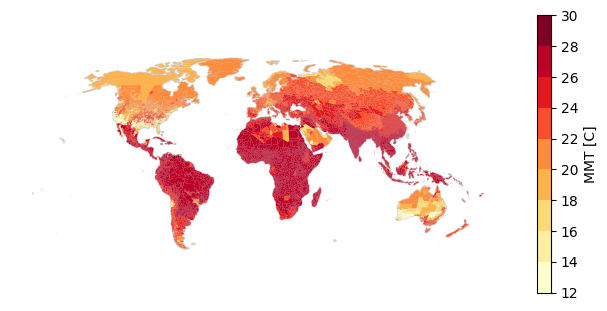

In [52]:
ax = analysis_utils.plot_single(
    _polygons_mmt,
    col="tas_bin",
    cm="YlOrRd",
    n_colors=10,
    vmin=12,
    vmax=30,
    sup_title="",
    cbar_label="MMT [C]",
)

In [45]:
_polygons_diff = analysis_utils.xarray_to_gpd(diff, _polygons)

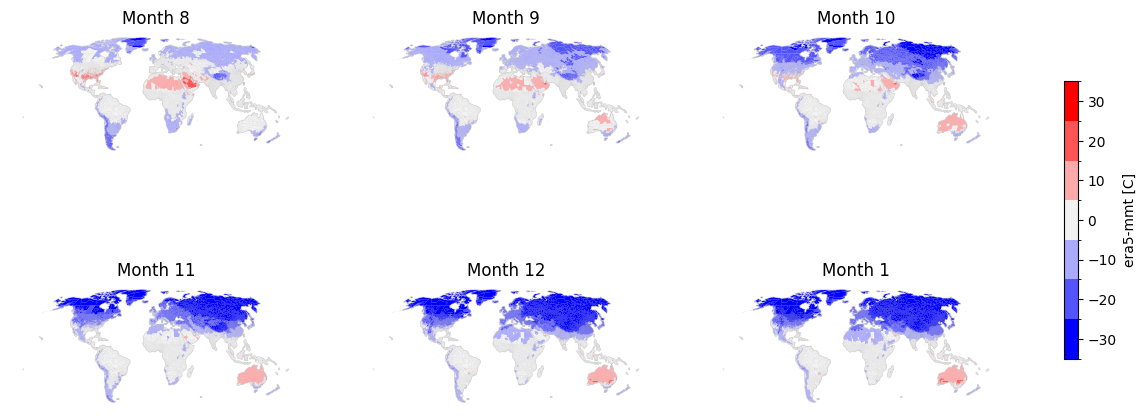

In [46]:
fig = analysis_utils.plot_monthly(
    _polygons_diff,
    col="value",
    cm="bwr",
    sup_title="",
    cbar_label="era5-mmt [C]",
    month_order=[8, 9, 10, 11, 12, 1],
)

In [53]:
forecast = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_URI))
# Gridded to Impact Region
forecast_ir = isku_utils.grid_to_ir(forecast.mean(dim="number"), savefile=None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [62]:
diff_forecast = (
    forecast_ir["tas"].groupby("time.month").mean()
    - 273.15
    - central_tas_bin.mean(dim="sample")
)

In [63]:
_polygons_forecast = analysis_utils.xarray_to_gpd(diff_forecast, _polygons)

In [ ]:
fig = analysis_utils.plot_monthly(
    _polygons_forecast,
    col="value",
    cm="bwr",
    vmin=-10,
    vmax=10,
    n_colors=13,
    sup_title="",
    cbar_label="forecast-mmt [C]",
    month_order=[8, 9, 10, 11, 12, 1],
)

In [70]:
com = diff_forecast / diff
_polygons_com = analysis_utils.xarray_to_gpd(com, _polygons)

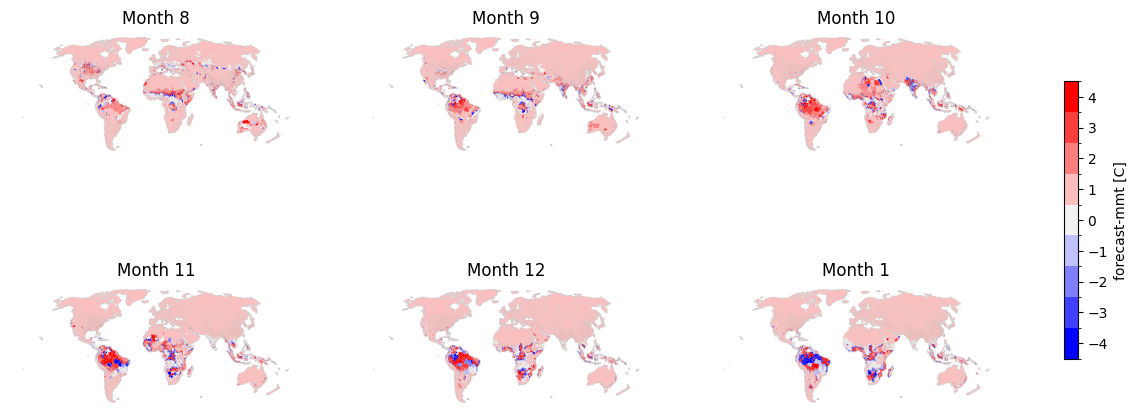

In [71]:
fig = analysis_utils.plot_monthly(
    _polygons_com,
    col="value",
    cm="bwr",
    sup_title="",
    cbar_label="forecast-mmt [C]",
    month_order=[8, 9, 10, 11, 12, 1],
)